In [3]:
import sys
print(sys.executable)

c:\Users\LENOVO\anaconda3\envs\nanophotonics-ml\python.exe


In [4]:
import numpy as np 
import miepython as mie
import pandas as pd 

np.random.seed(42)
n_samples = 3000

#input radius partikel (nm), indeks refraksi material, wavelength (nm)
radius = np.random.uniform(20, 200, n_samples)
diameter = 2 * radius
n_material = np.random.uniform(1.3, 2.5, n_samples)
wavelength = np.random.uniform(400, 800, n_samples)

# size parameter x = 2 * pi * r / lambda
x = 2 * np.pi * radius / wavelength
m = n_material # relative refractive index terhadap medium (medium = udara/vacuum, n=1)

qext, qsca, qback, g = mie.efficiencies(m,  diameter, wavelength)

df = pd.DataFrame({
    "radius_nm": radius,
    "n_material": n_material,
    "wavelength_nm": wavelength, 
    "qsca": qsca,
    "qext": qext
})
df.to_csv("mie_dataset.csv", index=False)

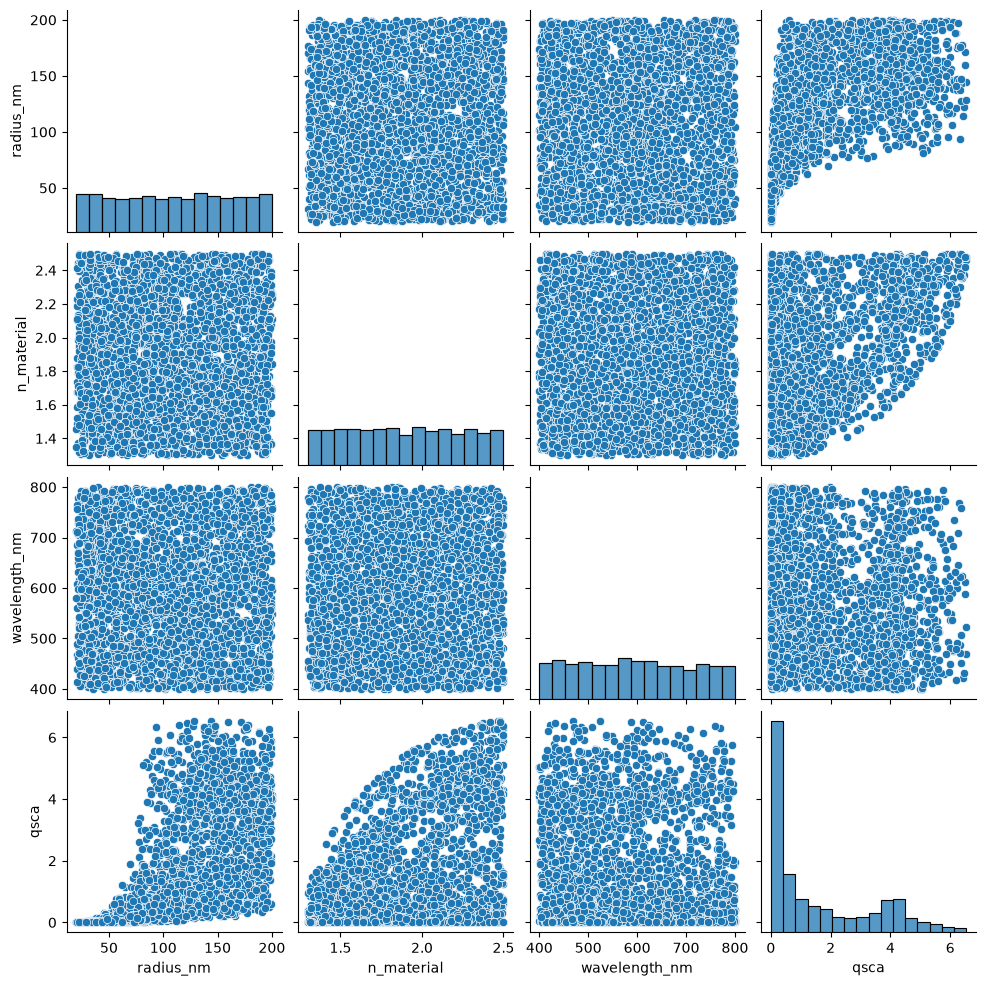

<Axes: >

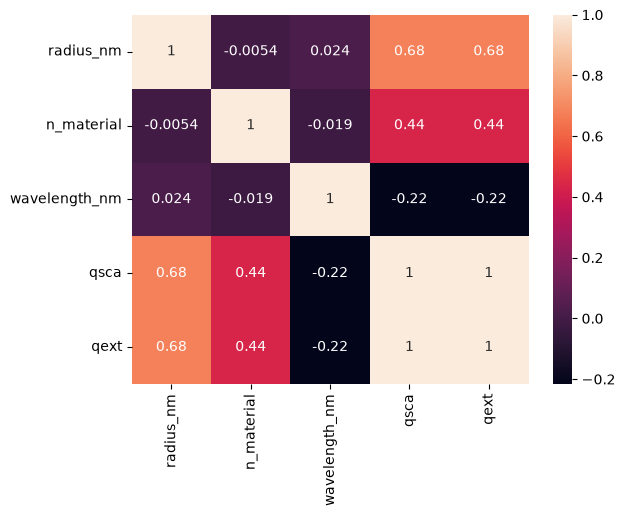

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df.describe()
sns.pairplot(df[["radius_nm", "n_material", "wavelength_nm", "qsca"]])
plt.show()

sns.heatmap(df.corr(), annot=True)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["radius_nm", "n_material", "wavelength_nm"]]
y = df[["qsca"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# baseline 1: Linear Regression
lr = LinearRegression().fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print("Linear R²:", r2_score(y_test, pred_lr))

# baseline 2: Random Forest (harusnya lebih bagus karena hubungannya non-linear)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("RF R²:", r2_score(y_test, pred_rf))

Linear R²: 0.6961772115351986


c:\Users\LENOVO\anaconda3\envs\nanophotonics-ml\Lib\site-packages\sklearn\base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF R²: 0.9622708620257386


Text(0.5, 1.0, 'Random Forest: Predicted vs Actual')

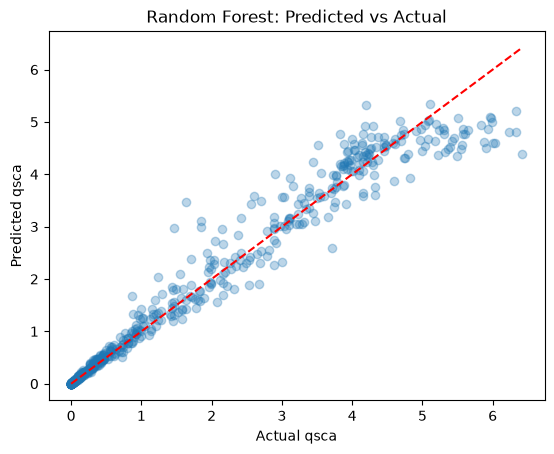

In [8]:
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual qsca")
plt.ylabel("Predicted qsca")
plt.title("Random Forest: Predicted vs Actual")

In [9]:
X_inv = df[["wavelength_nm", "qsca"]]
y_inv = df["radius_nm"]

X_train, X_test, y_train, y_test = train_test_split(X_inv, y_inv, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled_inv = scaler.fit_transform(X_train)
X_test_scaled_inv = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# baseline 1: Linear Regression
lr = LinearRegression().fit(X_train_scaled_inv, y_train)
pred_lr = lr.predict(X_test_scaled_inv)
print("Linear R²:", r2_score(y_test, pred_lr))

# baseline 2: Random Forest (harusnya lebih bagus karena hubungannya non-linear)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_scaled_inv, y_train)
pred_rf = rf.predict(X_test_scaled_inv)
print("RF R²:", r2_score(y_test, pred_rf))

Linear R²: 0.4789991906964818
RF R²: 0.7264275864855309


Text(0.5, 1.0, 'Random Forest: Predicted vs Actual Inverse')

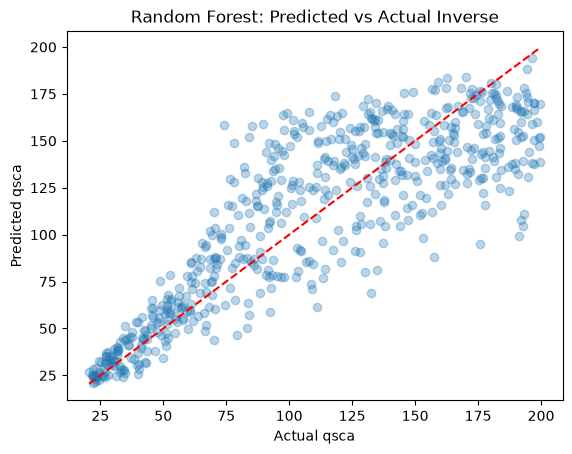

In [11]:
plt.scatter(y_test, pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual qsca")
plt.ylabel("Predicted qsca")
plt.title("Random Forest: Predicted vs Actual Inverse")

In [13]:
import pandas as pd
import numpy as np 
from scipy.interpolate import interp1d
import miepython as mie 

def load_nk_refractiveindex(path):
  with open(path) as f:
    content = f.read()

  blocks = content.strip().split("\n\n")
  n_df = pd.read_csv(pd.io.common.StringIO(blocks[0]))
  k_df = pd.read_csv(pd.io.common.StringIO(blocks[1]))
  n_interp = interp1d(n_df["wl"], n_df["n"], kind="cubic")
  k_interp = interp1d(k_df["wl"], k_df["k"], kind="cubic")
  return n_interp, k_interp

n_interp_si, k_interp_si = load_nk_refractiveindex("Aspnes.csv")


In [14]:
n_samples = 3000
np.random.seed(42)

wavelength = np.random.uniform(400, 800, n_samples)
radius = np.random.uniform(20, 200, n_samples)
diameter = 2 * radius

wl_um = wavelength / 1000
m = n_interp_si(wl_um) - 1j * k_interp_si(wl_um)

qext, qsca, qback, g = mie.efficiencies(m, diameter, wavelength)

df = pd.DataFrame({
  "radius_nm": radius,
  "wavelength_nm": wavelength,
  "n_real": m.real,
  "k_imag": -m.imag,
  "qsca": qsca,
  "qext": qext
})


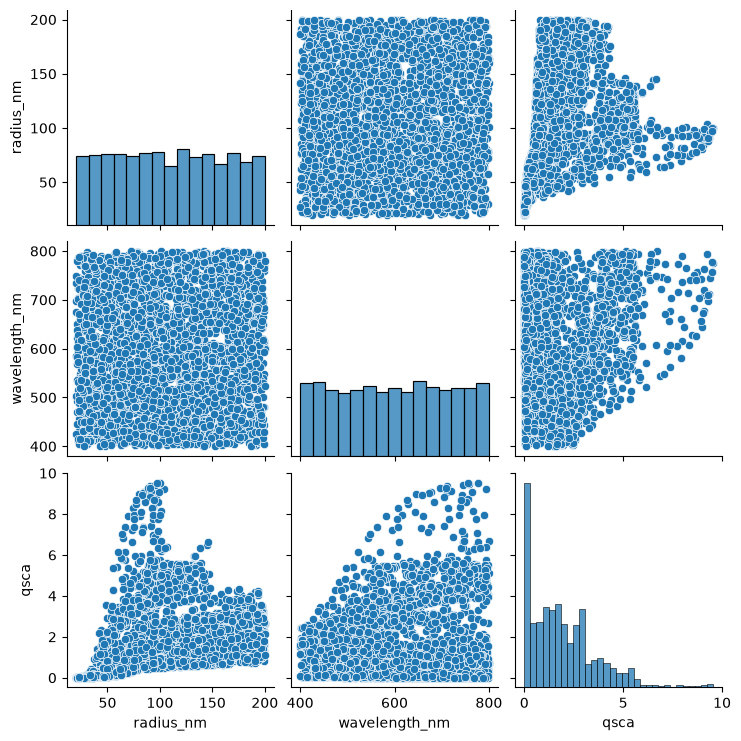

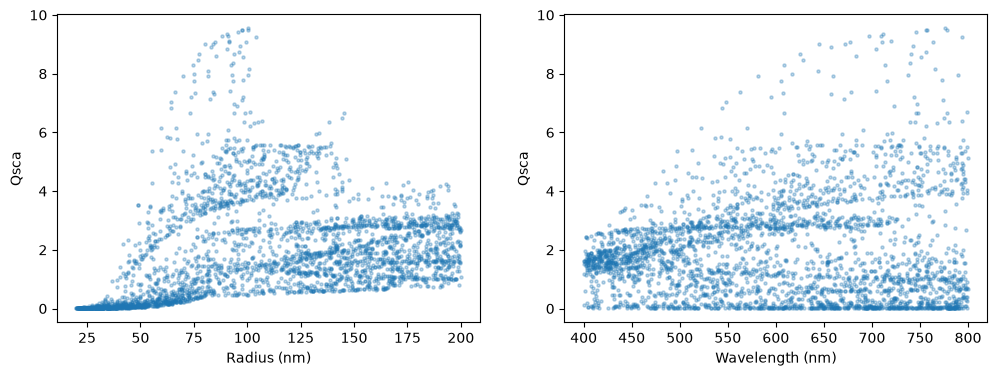

<Axes: >

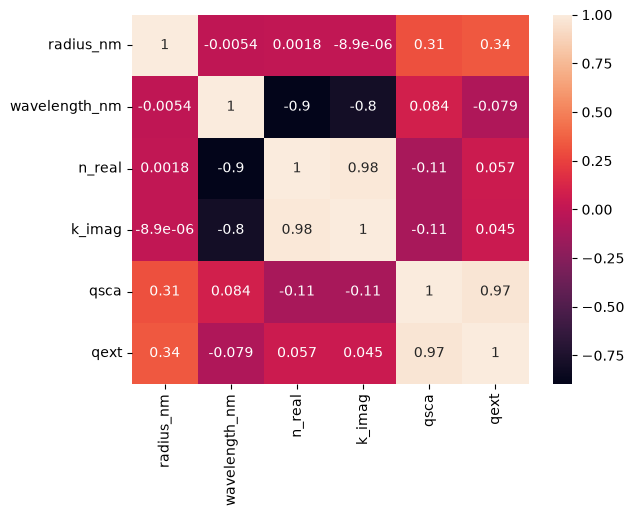

In [18]:
import matplotlib.pyplot as plt 
import seaborn as sns

df.describe()

sns.pairplot(df[["radius_nm", "wavelength_nm", "qsca"]])
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(df["radius_nm"], df["qsca"], alpha=0.3, s=5)
axes[0].set_xlabel("Radius (nm)"); axes[0].set_ylabel("Qsca")
axes[1].scatter(df["wavelength_nm"], df["qsca"], alpha=0.3, s=5)
axes[1].set_xlabel("Wavelength (nm)"); axes[1].set_ylabel("Qsca")
plt.show()

sns.heatmap(df[["radius_nm", "wavelength_nm", "n_real", "k_imag", "qsca", "qext"]].corr(), annot=True)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["radius_nm", "wavelength_nm"]]
y = df["qsca"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

lr = LinearRegression().fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
print("Linear R²:", r2_score(y_test, pred_lr))

rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
print("RF R²:", r2_score(y_test, pred_rf))



Linear R²: 0.08810120078473549
RF R²: 0.9066565073704475


In [21]:
X_inv = df[["wavelength_nm", "qsca"]]
y_inv = df["radius_nm"]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_inv, y_inv, test_size=0.2, random_state=42)

scaler_inv = StandardScaler()
X_train_i_scaled = scaler_inv.fit_transform(X_train_i)
X_test_i_scaled = scaler_inv.transform(X_test_i)

rf_inv = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train_i_scaled, y_train_i)
pred_inv = rf_inv.predict(X_test_i_scaled)
print("RF R² (inverse):", r2_score(y_test_i, pred_inv))

RF R² (inverse): 0.6797793664753484


In [22]:
import numpy as np
import miepython as mie
import matplotlib.pyplot as plt

radius_fixed = 50
diameter_fixed = 2 * radius_fixed

wavelength_sweep = np.linspace(400, 800, 500)

wl_um_sweep = wavelength_sweep / 1000
m_sweep = n_interp_si(wl_um_sweep) - 1j * k_interp_si(wl_um_sweep)

qext_sweep, qsca_sweep, qback_sweep, g_sweep = mie.efficiencies(m_sweep, diameter_fixed, wavelength_sweep)

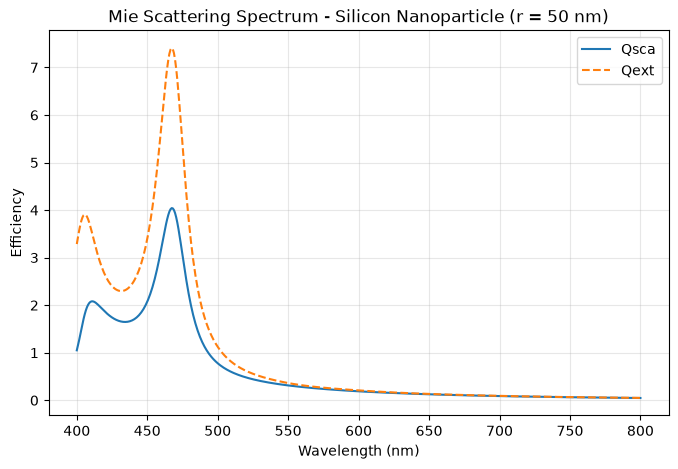

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(wavelength_sweep, qsca_sweep, label="Qsca")
plt.plot(wavelength_sweep, qext_sweep, label="Qext", linestyle='--')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Efficiency")
plt.title(f"Mie Scattering Spectrum - Silicon Nanoparticle (r = {radius_fixed} nm)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
df_r50 = pd.DataFrame({
  "wavelength_nm": wavelength_sweep,
  "qsca": qsca_sweep,
  "qext": qext_sweep
})
df_r50.head()

,wavelength_nm,qsca,qext
0,400.000000,1.050741,3.285731
1,400.801603,1.149429,3.427735
2,401.603206,1.257709,3.559996
3,402.404810,1.372322,3.677086
4,403.206413,1.489114,3.773884


In [25]:
peak_idx = df_r50["qsca"].idxmax()
print(f"Peak Qsca at wavelength: {df_r50.loc[peak_idx, 'wavelength_nm']} nm")
print(f"Qsca: {df_r50.loc[peak_idx, 'qsca']}")

Peak Qsca at wavelength: 467.3346693386774 nm
Qsca: 4.041516858457087


In [26]:
import numpy as np
import miepython as mie
import matplotlib.pyplot as plt

radius_fixed = 50
diameter_fixed = 2 * radius_fixed
wavelength_sweep = np.linspace(400, 800, 500)
wl_um_sweep = wavelength_sweep / 1000
m_sweep = n_interp_si(wl_um_sweep) - 1j * k_interp_si(wl_um_sweep)

n_max = 3 # hitung sampai oder ke-3: dipole, quadrupole, octopole

qsca_electric = np.zeros((n_max, len(wavelength_sweep)))
qsca_magnetic = np.zeros((n_max, len(wavelength_sweep)))

for i, (wl, m_val) in enumerate(zip(wavelength_sweep, m_sweep)):
  x = np.pi * diameter_fixed / wl
  a, b = mie.coefficients(m_val, x, n_pole=n_max)
  for n in range(1, n_max + 1):
    qsca_electric[n-1, i] = (2/x**2) * (2*n+1) * abs(a[n-1])**2
    qsca_magnetic[n-1, i] = (2/x**2) * (2*n+1) * abs(b[n-1])**2

qsca_total_check = qsca_electric.sum(axis=0) + qsca_magnetic.sum(axis=0)

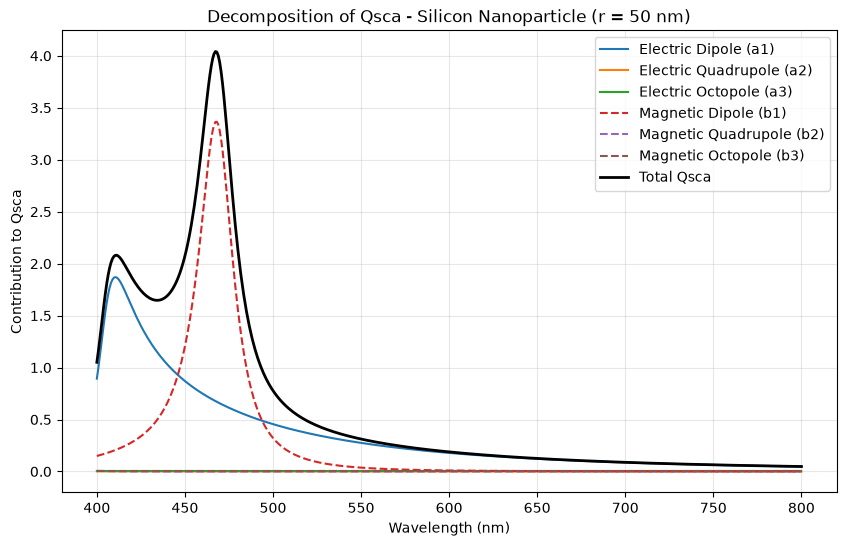

In [27]:
labels_e = ["Electric Dipole (a1)", "Electric Quadrupole (a2)", "Electric Octopole (a3)"]
labels_m = ["Magnetic Dipole (b1)", "Magnetic Quadrupole (b2)", "Magnetic Octopole (b3)"]

plt.figure(figsize=(10, 6))
for n in range(n_max):
    plt.plot(wavelength_sweep, qsca_electric[n], label=labels_e[n])
for n in range(n_max):
    plt.plot(wavelength_sweep, qsca_magnetic[n], label=labels_m[n], linestyle='--')
plt.plot(wavelength_sweep, qsca_total_check, label="Total Qsca", color='black', linewidth=2)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Contribution to Qsca")
plt.title(f"Decomposition of Qsca - Silicon Nanoparticle (r = {radius_fixed} nm)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

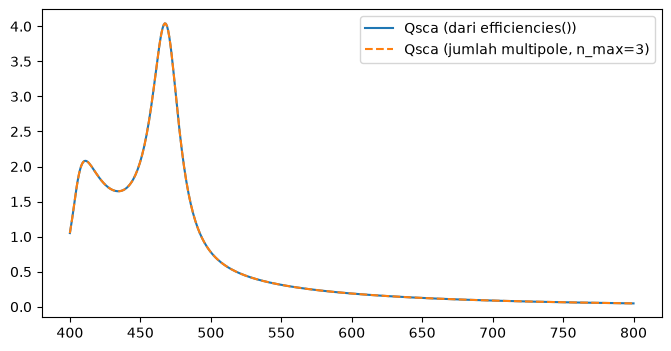

In [28]:
plt.figure(figsize=(8,4))
plt.plot(wavelength_sweep, qsca_sweep, label="Qsca (dari efficiencies())")
plt.plot(wavelength_sweep, qsca_total_check, "--", label="Qsca (jumlah multipole, n_max=3)")
plt.legend()
plt.show()